# Prediction quality across the predictive-heads campaign

This notebook measures how molecule prediction quality differs across the 8 declared
`vpu_precision_sweep` loss conditions (masked/positive-weighted multi-label BCE variants,
a three-state PNU head, a variational PU bound, a symmetric PU ranking loss) and the
`vpu_precision_sweep` baseline. `part_3` measures the representation directly; this notebook
measures what the classifier does with it, and `part_7` (decision summary, once built)
combines the two.

## Introduction

Unlike the contractive campaign's single fixed head evaluated at a fixed threshold, this
campaign's conditions are genuinely different *objectives* over a shared evidence policy
(positive/negative/unlabelled per pixel per class). Evaluation therefore uses two fixed
populations rather than one class scope:

- **`annotation_retrieval`** — every entry the evidence policy did not mark unavailable
  (positive or negative), the broad population;
- **`operational_pn`** — only entries confidently marked positive or negative (excludes
  the ambiguous/unlabelled middle), the population closest to a clean two-class problem.

Within each population, classes are further split into **scopes**: `train_supported`
(every class with at least one training positive), and `rare`/`medium`/`frequent`
frequency bands. Threshold-free ranking metrics (`average_precision`, `roc_auc`, and the
prevalence-relative `ap_above_prevalence`) are reported for every condition. A second,
threshold-dependent family — macro/micro F1, precision, recall, Hamming loss, the
metrics `05_09_26_contractive_expaned/part_0_old_vs_new_split_bce.ipynb` reports for its
single fixed binary head — is reported for **17 of the 20 conditions**: every condition
whose training objective's own theory makes `sigmoid(score)` a genuine, checkable
estimate of the positive-class probability, not only the literal-BCE-trained ones (see
the "Threshold-based prediction metrics" section for the exact formulas and the full
per-family breakdown). Only 3 conditions are excluded: `pu_ranking` (its ranking
surrogate has no absolute anchor at all — shift-invariant by construction, not merely
unproven) and the two three-state heads `pnu_ce`/`observed_pnu_cross_entropy` (a genuine
three-way decision, answered properly by `part_8_pnu_state_discrimination.ipynb`'s
`argmax`-based confusion analysis instead of a secondary binary proxy here).

### Assumptions

- **The compared models share their data and evidence policy.** All `vpu_precision_sweep`
  conditions use the same backbone, dataset contract and evidence thresholds
  (`part_0_0` verifies the manifests); only the classification-head loss differs.
  `vpu_precision_sweep` is a separately trained model, not a repetition of this grid (see
  `part_0_0`'s own assumption on this).
- **A class must be eligible to enter a macro average.** `average_precision`/`roc_auc`
  are undefined for a class with no available positive or no available negative in a
  population; such classes are excluded from every macro mean below (`eligible` in the
  base `per_class` table), not scored as zero.
- **Threshold metrics are excluded only where no meaningful 0.5 threshold exists at
  all, not merely where it wasn't literally trained with BCE.** `pu_ranking`'s score is
  shift-invariant by construction (`l(d) + l(-d) = 1` regardless of any additive offset
  to the whole score), so no absolute anchor exists, full stop. The three-state heads
  make a genuine three-way decision, already answered properly in `part_8`. Every other
  condition — including the VPU/Taylor-VPU/DeepGambler/Evidential/JERM objectives,
  whose own theory targets a real positive-class probability even though the training
  loss is not literal `binary_cross_entropy_with_logits` — gets real numbers (see the
  "Threshold-based prediction metrics" section for exactly why each one qualifies).
- **Five repetitions per condition bound seed noise, not the population.**

### Notation

For condition $c$ and repetition $r$, $\mathrm{AP}_c(r)$ is the macro average precision
over eligible classes in population $p$ and scope $s$. $\mathrm{AP}_c$ denotes its mean
over repetitions. $n^{\mathrm{train}}_k$ is class $k$'s training positive count.

For the threshold metrics, per class $k$ with predicted positive set
$\hat P_k = \{i : \sigma(s_{ik}) \geq 0.5\}$ and true positive set $P_k$ (both restricted
to the population's available entries): $\mathrm{precision}_k = |\hat P_k \cap P_k| /
|\hat P_k|$, $\mathrm{recall}_k = |\hat P_k \cap P_k| / |P_k|$, $F1_k = 2\,
\mathrm{precision}_k\, \mathrm{recall}_k / (\mathrm{precision}_k + \mathrm{recall}_k)$
(each $0$ when its denominator is $0$, matching `sklearn`'s `zero_division=0`). Macro
values average these over eligible classes; micro values pool every eligible class's
entries into one confusion count before taking the ratio. Hamming loss is the pooled
mismatch rate $|\{(i,k) : \mathbb{1}[\sigma(s_{ik}) \geq 0.5] \neq y_{ik}\}| /
|\text{pooled entries}|$ — a single flat number, no macro/micro distinction (no natural
per-class average of "fraction of cells wrong" is more informative than the pooled rate
here, matching `part_0`'s own `evaluate_head` reference implementation).

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("prediction_global")

from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)


2026-09-19 23:26:24,206 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-09-19 23:26:24,214 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-09-19 23:26:25,086 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.
2026-09-19 23:26:25,089 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.
2026-09-19 23:26:25,104 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.
2026-09-19 23

## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

No new precompute routine backs this notebook: `prediction`, `per_class` and
`score_diagnostics` are already written by the base full-campaign inference cache
(`predictive_precompute.precompute`), one row per (model, split, population, scope,
metric). This notebook only derives cheap summaries from tables already on disk.

If those tables are missing, `predictive_precompute.load_table` names the base
precompute command that produces them.

### Remarks

### Notes

In [2]:
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive/analysis_settings.yaml")
NOTEBOOK_DIR = SETTINGS_PATH.parent
RESULTS = NOTEBOOK_DIR / "part_4_prediction_global_results"
RESULTS.mkdir(exist_ok=True)

settings = campaign.load_settings(SETTINGS_PATH)
settings["settings_path"] = str(SETTINGS_PATH)
SAMPLE_SEED = int(settings["sample_seed"])

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

In [3]:
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import (
    load_model_catalog, load_visualization_theme, select_catalog_frame,
)
models = load_model_catalog(settings)
ready = models[models.ready]
prediction = cache.load_table(settings, "prediction")
per_class = cache.load_table(settings, "per_class")
score_diagnostics = cache.load_table(settings, "score_diagnostics")
prediction = select_catalog_frame(prediction, models)
per_class = select_catalog_frame(per_class, models)
score_diagnostics = select_catalog_frame(score_diagnostics, models)

CONDITION_ORDER = reports.condition_order(ready)
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}
POPULATION = "annotation_retrieval"   # primary population; operational_pn is the secondary, cleaner-label one
SPLIT = "test"

print(f"{ready.model_id.nunique()} ready model(s), {len(prediction)} prediction row(s), "
     f"{len(per_class)} per-class row(s) over {per_class.class_index.nunique()} class(es)")
print(f"populations: {sorted(prediction.population.unique())}, scopes: {sorted(prediction.scope.unique())}")

130 ready model(s), 3720 prediction row(s), 60960 per-class row(s) over 508 class(es)
populations: ['annotation_retrieval', 'operational_pn'], scopes: ['frequent', 'medium', 'rare', 'train_supported']


## Prediction metrics across the campaign

### Methodology

#### Theoretical

`average_precision` and `roc_auc` are threshold-free ranking metrics; `ap_above_prevalence`
is average precision minus the class's own positive prevalence, i.e. how much better than
"guess the base rate" the ranking is — a class with 90% prevalence and 0.91 AP is barely
informative, while the same AP on a 1%-prevalent class is not. All three are reported per
population and scope so a change confined to rare classes or to one evidence population is
visible rather than averaged away.

#### Implementation

Values come directly from the base cache's `prediction` table (already computed by
`heads.predictive_comparison.ranking_tables`); nothing is recomputed here.

#### Figure descriptions

Table: one row per condition (baseline first), columns the three metrics, population
`annotation_retrieval`, scope `train_supported`, evaluation split, mean over repetitions.

### Remarks

### Notes

In [4]:
METRIC_ORDER = ["average_precision", "roc_auc", "ap_above_prevalence"]
summary_table = (
    prediction.query("split == @SPLIT and population == @POPULATION and scope == 'train_supported' and metric in @METRIC_ORDER")
    .pivot_table(index="label", columns="metric", values="value", aggfunc="mean")
    .reindex(CONDITION_ORDER)[METRIC_ORDER]
)
display(summary_table.round(4))

metric,average_precision,roc_auc,ap_above_prevalence
label,,,
vpu,NaN,NaN,NaN
vpu + contrastive,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.01, w=0.001)",NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.01, w=0.01)",NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.01, w=0.1)",NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.07, w=0.001)",0.6810,0.9895,0.6317
"VPU + contractive + contrastive (T=0.07, w=0.01)",NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.15, w=0.001)",NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.15, w=0.01)",NaN,NaN,NaN


## Distribution of every metric across repetitions

### Methodology

#### Theoretical

A mean over five repetitions cannot distinguish a consistent shift from one divergent
seed. Every metric is therefore shown as its full distribution, every repetition drawn.

#### Implementation

One panel per metric, one violin per condition, all repetition values overlaid as
points. The dashed line marks the baseline's mean.

#### Figure descriptions

Grid of panels, x-axis condition (baseline first), y-axis the metric on the evaluation
split, population `annotation_retrieval`, scope `train_supported`. Color encodes the
condition; the dashed horizontal line is the baseline's mean.

### Remarks

### Notes

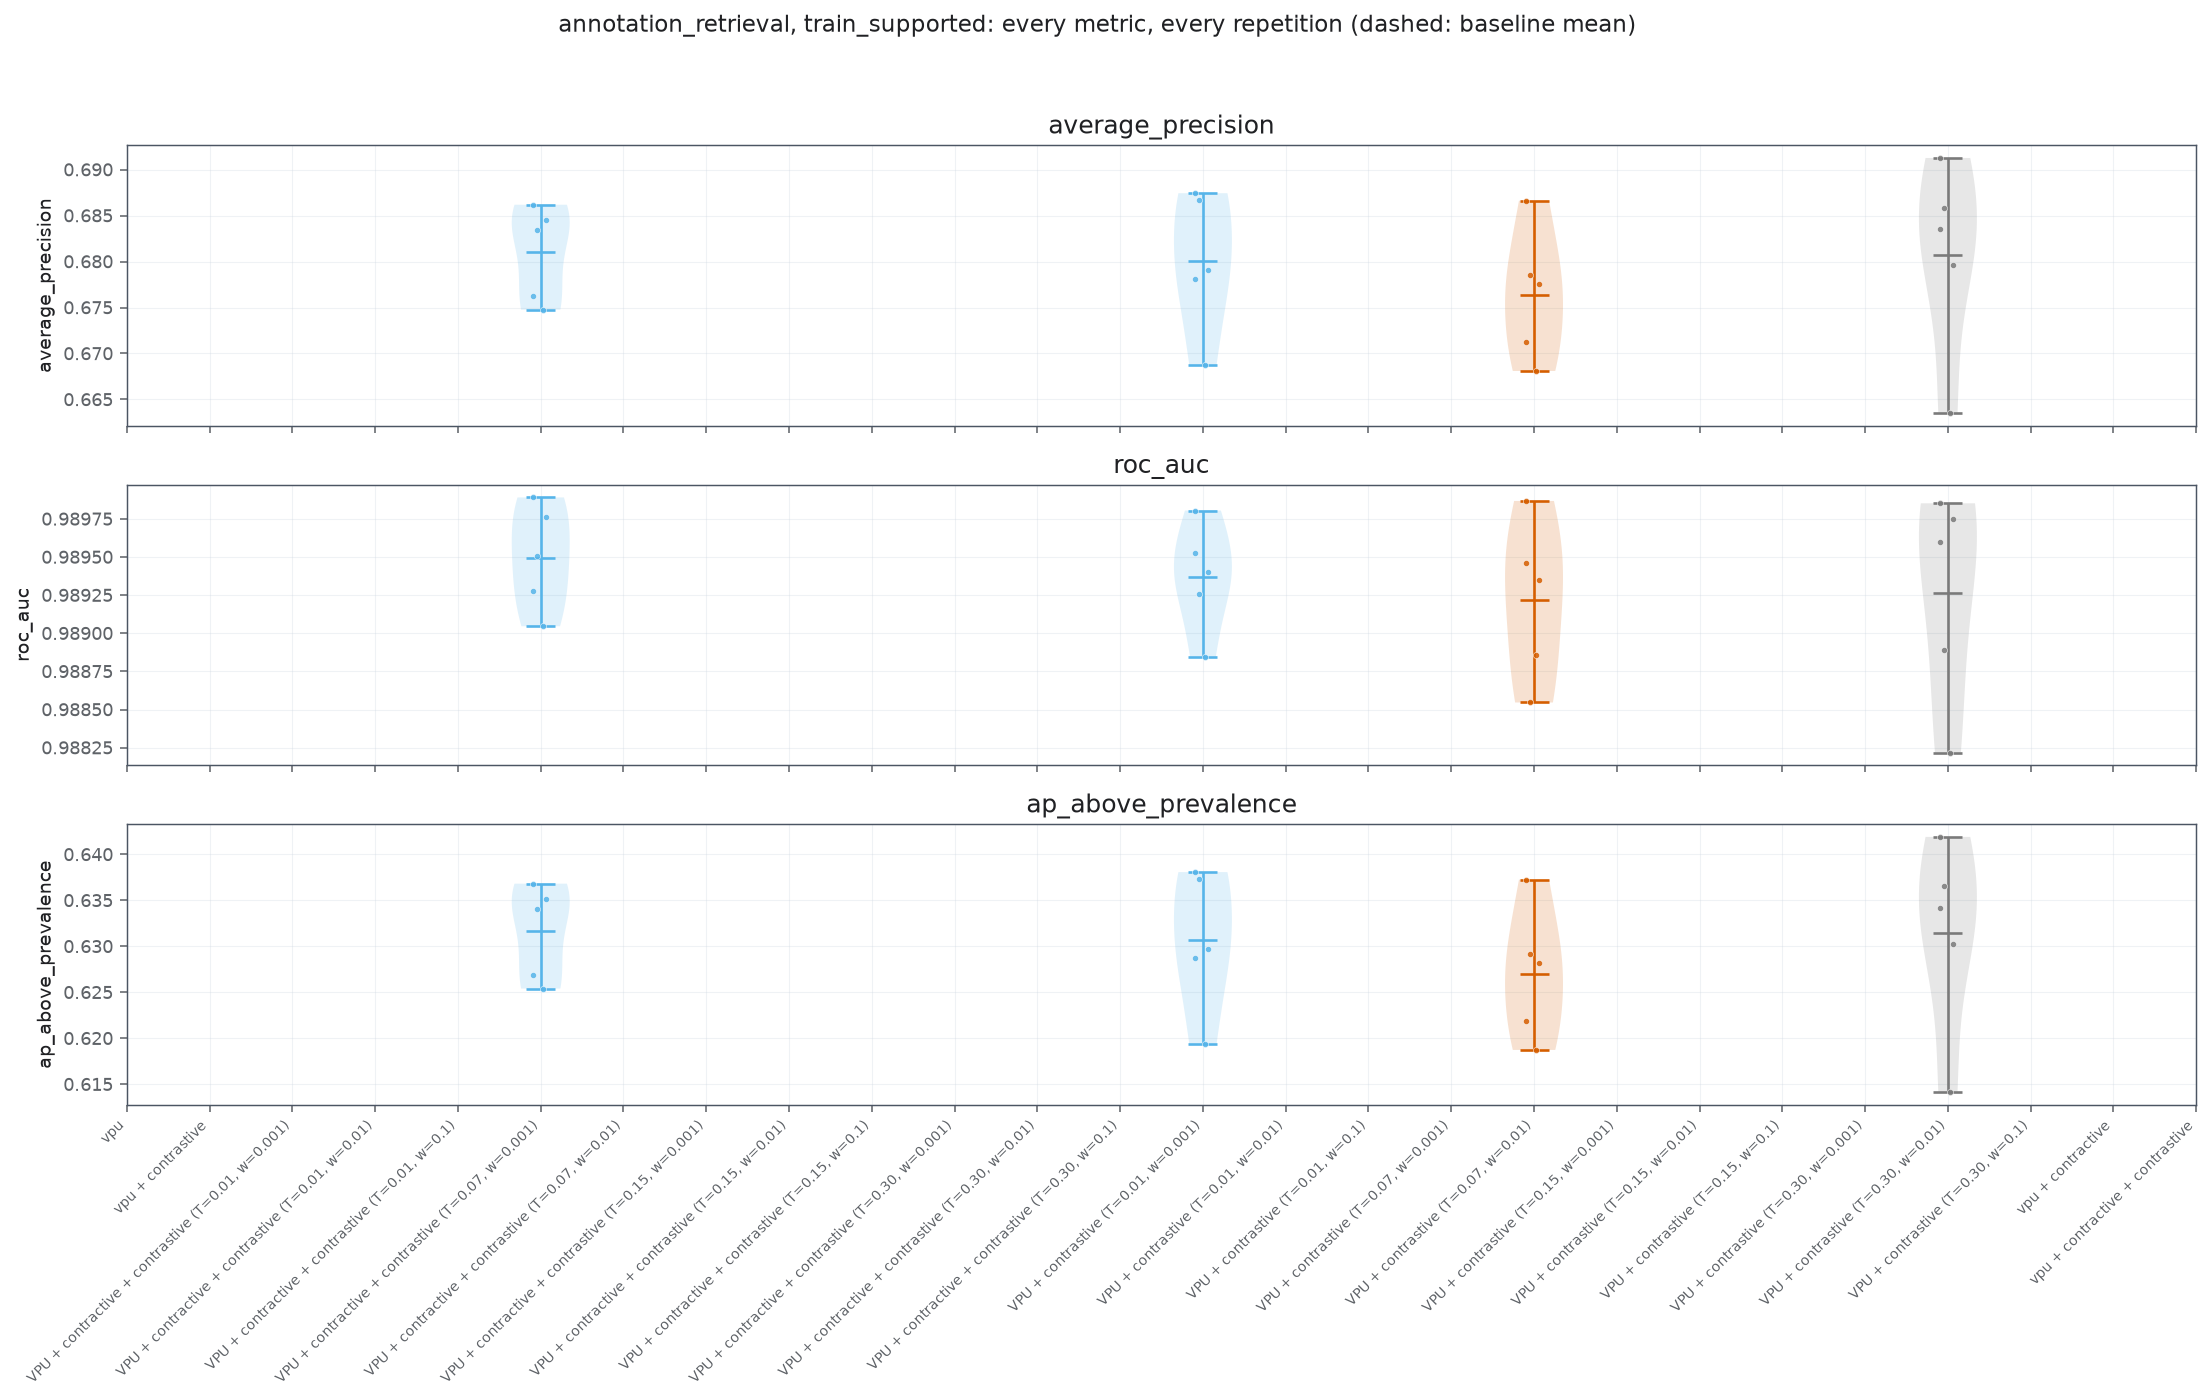

In [5]:
def metric_samples(metric, *, population=POPULATION, scope="train_supported", split=SPLIT):
    selected = prediction.query("metric == @metric and population == @population and scope == @scope and split == @split")
    return {label: group["value"].to_numpy() for label, group in selected.groupby("label")}

baseline_label = ready.query("role == 'baseline'").label.iloc[0]

figure, axes = plt.subplots(len(METRIC_ORDER), 1, figsize=(16, 10), dpi=theme.figure_dpi, sharex=True)
for axis, metric in zip(np.atleast_1d(axes), METRIC_ORDER):
    samples = metric_samples(metric)
    for position, label in enumerate(CONDITION_ORDER):
        values = samples.get(label)
        if values is None or not len(values):
            continue
        plot_violin_with_points(values, position=position, ax=axis, width=0.7, color=LABEL_COLOR[label], point_size=10.0, jitter=0.10, theme=theme)
    if baseline_label in samples:
        axis.axhline(float(np.mean(samples[baseline_label])), color="grey", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(CONDITION_ORDER)))
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
for axis in np.atleast_1d(axes)[:-1]:
    axis.tick_params(axis="x", labelbottom=False)
np.atleast_1d(axes)[-1].set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)
figure.suptitle(f"{POPULATION}, train_supported: every metric, every repetition (dashed: baseline mean)", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.97))

## Threshold-based prediction metrics (17 of 20 conditions)

### Methodology

#### Theoretical

`average_precision`/`roc_auc` are threshold-free; they say nothing about what happens
at a fixed decision boundary. Macro/micro F1, precision, recall and Hamming loss — the
metrics `05_09_26_contractive_expaned/part_0_old_vs_new_split_bce.ipynb`'s
`evaluate_head`/`per_class_metrics` report for its single fixed binary head — require
`sigmoid(score)` to be a genuine, model-intrinsic estimate of the positive-class
probability. That is a weaker requirement than "trained with literal
`binary_cross_entropy_with_logits`": every family below targets that same quantity by
its own theory, even where the training objective is a variational bound, a Dirichlet
KL term or a missingness-aware likelihood instead of plain BCE.

**Eligible (17 conditions), and why `sigmoid(score)` is a real probability for each:**

- `ClassBalancedMultiLabelBCELoss`, `MultiLabelBCELoss`,
  `PositiveWeightedMultiLabelBCELoss`, `BCEPNLoss`, `SignalMaskedBCELoss` — literal
  `binary_cross_entropy_with_logits` against the true label; the textbook case.
- `SelectivePNLoss`, `SelectiveTaylorVariationalPULoss` — `SelectiveHead`'s `classifier`
  channel (index 0) is *also* literal BCE-trained (`selective_losses.py`/
  `selective_taylor_pu_loss.py`); the `selection`/`auxiliary` channels are an unrelated
  abstention mechanism, ignored here exactly as in ranking (see
  `heads.predictive_comparison.SELECTIVE_FAMILIES`).
- `VariationalPULoss`, `TaylorVariationalPULoss` — the variational PU bound's entire
  theoretical point (Chen et al., NeurIPS 2020; Zhao et al., ICCV 2023) is to make the
  trained sigmoid output a valid posterior estimate under an *unknown* class prior —
  not literal BCE, but the identical target quantity BCE estimates under a known one.
- `EvidentialTaylorVariationalPULoss` — `sigmoid(score)` reconstructs exactly the
  Dirichlet mean $\alpha_P / (\alpha_P + \alpha_N)$ with $\alpha = \mathrm{softplus}
  (\text{raw}) + 1$ (`EvidentialTaylorVariationalPULoss.concentrations`/`probability`,
  reproduced not reimported); this *is* the loss's own positive-probability estimate.
- `JERMLoss` — `sigmoid(posterior\_logit)` is literally what the posterior branch is
  trained to represent (`jerm_head.py`'s own docstring; the same channel `positive_scores`
  already ranks on).
- `DeepGamblerPNLoss`, `DeepGamblerTaylorVariationalPULoss` — `sigmoid(score)`
  reconstructs the model's own categorical `positive` probability under its 3-way
  softmax: the plain family's marginal $p(P)$, the Taylor-hybrid's conditional
  $p(P \mid \text{accepted})$ (excludes the `reserve`/abstention mass by the hybrid's
  own definition, see `positive_scores`) — still a genuine, checkable probability the
  model itself computes, not merely a rank.

**Excluded (3 conditions) — no meaningful threshold exists, not merely an untested one:**

- `SymmetricPURankingLoss` (`pu_ranking`) — the pairwise surrogate satisfies
  $\ell(d) + \ell(-d) = 1$ for any score difference $d$ *regardless of an additive
  offset to the whole score*, so nothing anchors `sigmoid(score)` to an absolute
  probability scale at all.
- `ThreeStateCrossEntropyLoss`, `ObservedPNUSCrossEntropyLoss` (`pnu_ce`,
  `observed_pnu_cross_entropy`) — these make a genuine three-way N/P/U decision. Their
  `sigmoid(positive_scores)` *does* equal a real softmax probability (the same identity
  used for `DeepGamblerPNLoss` above), but collapsing that back into a binary "positive
  vs. everything" cutoff here would be a strictly worse, redundant proxy for
  `part_8_pnu_state_discrimination.ipynb`'s dedicated `argmax`-based three-way
  confusion analysis (`heads.predictive_comparison.state_confusion`) — that notebook
  answers the actually-relevant question (does the head's own three-way decision
  separate N from U) directly, so no number is reported here instead.

#### Implementation

Computed inside the same `heads.predictive_comparison.ranking_tables` call that
produces the ranking metrics above (`precision`/`recall`/`f1` per class and macro;
`micro_precision`/`micro_recall`/`micro_f1`/`hamming_loss` pooled over eligible
classes' available entries at the same 0.5 cutoff), gated per condition by
`predictive_comparison._threshold_eligible` (`THRESHOLD_ANCHORED_FAMILIES`). Same
populations/scopes/eligibility as the ranking table above. Formulas are in this
notebook's own Notation section.

REMARK: while adding this, an unrelated pre-existing scoring bug was found and fixed
upstream, in `heads.predictive_comparison.positive_scores`/`_score_tensor`. Both
`SelectiveHead`'s `(classifier, selection, auxiliary)` and `EvidentialHead`'s
`(negative_evidence, positive_evidence)` outputs were being read with the channel
convention meant for the unrelated N/P/U and JERM heads, which happen to share their
shapes. This is exactly what produced the near-zero/inverted `average_precision`/
`roc_auc` seen above for `selective_pn`, `selective_taylor_vpu_plus_simulated_negative`
and `evidential_taylor_vpu`; those ranking numbers changed once the correct channel
(the classifier logit; the Dirichlet mean positive log-odds) is used, and every table
in this notebook now reflects the fix.

#### Figure descriptions

Table: one row per condition (baseline first), columns macro precision/recall/F1,
micro precision/recall/F1 and Hamming loss; population `annotation_retrieval`, scope
`train_supported`, evaluation split, mean over repetitions. Ineligible conditions show
`NaN` in every column.

### Remarks

### Notes

In [6]:
THRESHOLD_METRIC_ORDER = ["f1", "precision", "recall", "micro_f1", "micro_precision", "micro_recall", "hamming_loss"]
threshold_summary_table = (
    prediction.query("split == @SPLIT and population == @POPULATION and scope == 'train_supported' and metric in @THRESHOLD_METRIC_ORDER")
    .pivot_table(index="label", columns="metric", values="value", aggfunc="mean")
    .reindex(CONDITION_ORDER)[THRESHOLD_METRIC_ORDER]
)
display(threshold_summary_table.round(4))

metric,f1,precision,recall,micro_f1,micro_precision,micro_recall,hamming_loss
label,,,,,,,
vpu,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vpu + contrastive,NaN,NaN,NaN,NaN,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.01, w=0.001)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.01, w=0.01)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.01, w=0.1)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.07, w=0.001)",0.4816,0.5360,0.4936,0.8444,0.8345,0.8545,0.0155
"VPU + contractive + contrastive (T=0.07, w=0.01)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.15, w=0.001)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
"VPU + contractive + contrastive (T=0.15, w=0.01)",NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution of threshold-based metrics across repetitions

### Methodology

#### Theoretical

Same rationale as the ranking-metric distribution above: a mean over five repetitions
cannot distinguish a consistent shift from one divergent seed.

#### Implementation

One panel per threshold metric, one violin per condition, all repetition values
overlaid as points. Ineligible conditions contribute no finite values and are simply
absent from their panels. The dashed line marks the baseline's mean.

#### Figure descriptions

Grid of panels (one empty), x-axis condition, y-axis the metric on the evaluation
split, population `annotation_retrieval`, scope `train_supported`. Color encodes the
condition; the dashed horizontal line is the baseline's mean.

### Remarks

### Notes

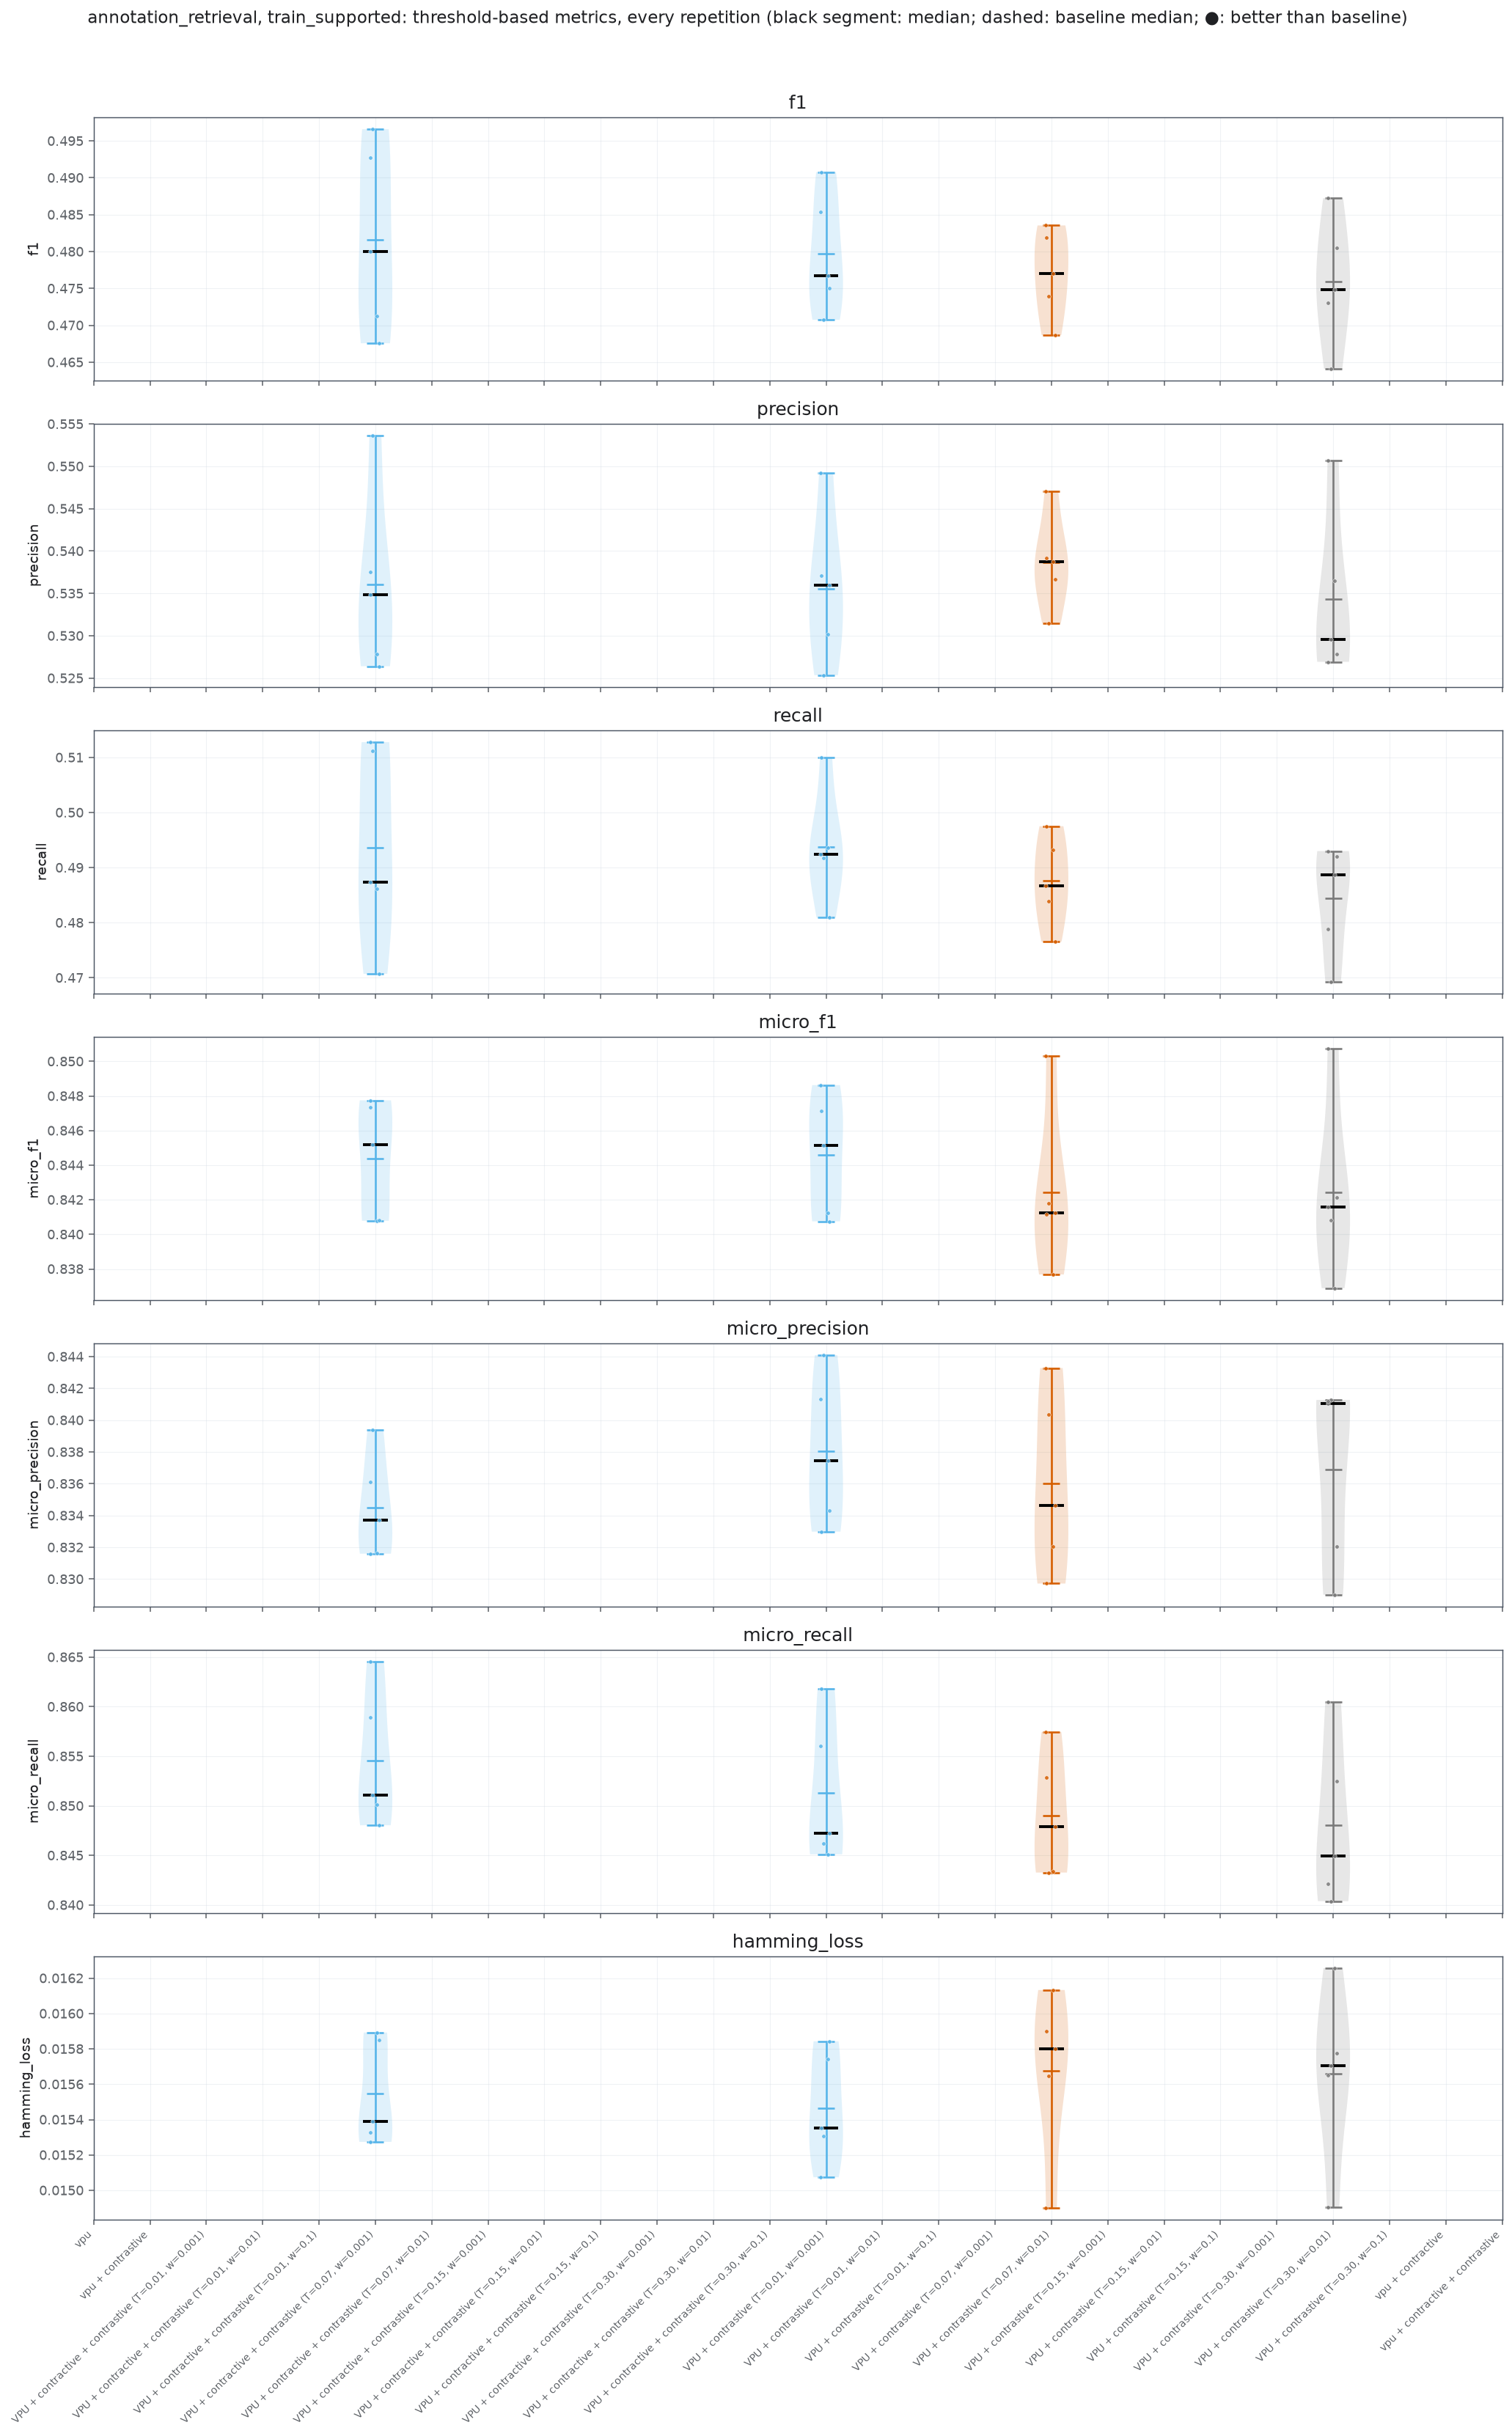

In [7]:
THRESHOLD_METRICS = ["f1", "precision", "recall", "micro_f1", "micro_precision", "micro_recall", "hamming_loss"]

figure, axes = plt.subplots(len(THRESHOLD_METRICS), 1, figsize=(15.0, 3.4 * len(THRESHOLD_METRICS)), dpi=theme.figure_dpi, sharex=True)

for axis, metric in zip(np.atleast_1d(axes), THRESHOLD_METRICS):
    samples = metric_samples(metric)
    medians = {}

    for position, label in enumerate(CONDITION_ORDER):
        values = samples.get(label)
        if values is None or not len(values) or not np.isfinite(values).any():
            continue
        values = values[np.isfinite(values)]
        median = float(np.median(values))
        medians[label] = median

        plot_violin_with_points(values, position=position, ax=axis, width=0.6, color=LABEL_COLOR[label], point_size=8.0, jitter=0.10, theme=theme)
        axis.hlines(median, position - 0.22, position + 0.22, color="black", linewidth=2.0)

    baseline_values = samples.get(baseline_label)
    if baseline_values is not None and np.isfinite(baseline_values).any():
        baseline_median = float(np.nanmedian(baseline_values))
        axis.axhline(baseline_median, color="grey", linestyle="--", linewidth=1.2)

        for position, label in enumerate(CONDITION_ORDER):
            if label not in medians:
                continue
            better = medians[label] < baseline_median if metric == "hamming_loss" else medians[label] > baseline_median
            if better:
                axis.text(position, 0.97, "●", transform=axis.get_xaxis_transform(), ha="center", va="top", fontsize=9, fontweight="bold", color="black")

    axis.set_xticks(range(len(CONDITION_ORDER)))
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)

for axis in np.atleast_1d(axes)[:-1]:
    axis.tick_params(axis="x", labelbottom=False)

axes[-1].set_xticks(range(len(CONDITION_ORDER)))
axes[-1].set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)

better_count = {label: 0 for label in CONDITION_ORDER}

for metric in THRESHOLD_METRICS:
    samples = metric_samples(metric)
    baseline_values = samples.get(baseline_label)
    if baseline_values is None or not np.isfinite(baseline_values).any():
        continue

    baseline_median = float(np.nanmedian(baseline_values))

    for label in CONDITION_ORDER:
        values = samples.get(label)
        if values is None or not np.isfinite(values).any():
            continue
        median = float(np.nanmedian(values))
        better = median < baseline_median if metric == "hamming_loss" else median > baseline_median
        if better:
            better_count[label] += 1

for tick, label in zip(axes[-1].get_xticklabels(), CONDITION_ORDER):
    if better_count[label] > len(THRESHOLD_METRICS) / 2:
        tick.set_fontweight("bold")
        tick.set_color("black")

figure.suptitle(
    f"{POPULATION}, train_supported: threshold-based metrics, every repetition "
    "(black segment: median; dashed: baseline median; ●: better than baseline)",
    y=0.995,
    fontsize=12,
)

figure.tight_layout(rect=(0, 0, 1, 0.98))

## Generalization gap between the training and evaluation split

### Methodology

#### Theoretical

The gap $\mathrm{AP}^{\mathrm{train}}_c-\mathrm{AP}^{\mathrm{test}}_c$ tells whether a
condition merely memorizes the training annotations. Because a positive-weighting scheme
directly targets the training class balance, a gap difference here is informative in a way
it would not be for a plain reconstruction objective.

#### Implementation

The gap is computed per repetition, pairing each run's own training and evaluation
values, then shown as a distribution across repetitions.

#### Figure descriptions

Left: per condition, the distribution over repetitions of the paired train-minus-test
average precision gap; zero means identical performance on both splits. Right: the two
absolute levels per condition (mean over repetitions), training as open markers,
evaluation as filled markers, connected per condition.

### Remarks

### Notes

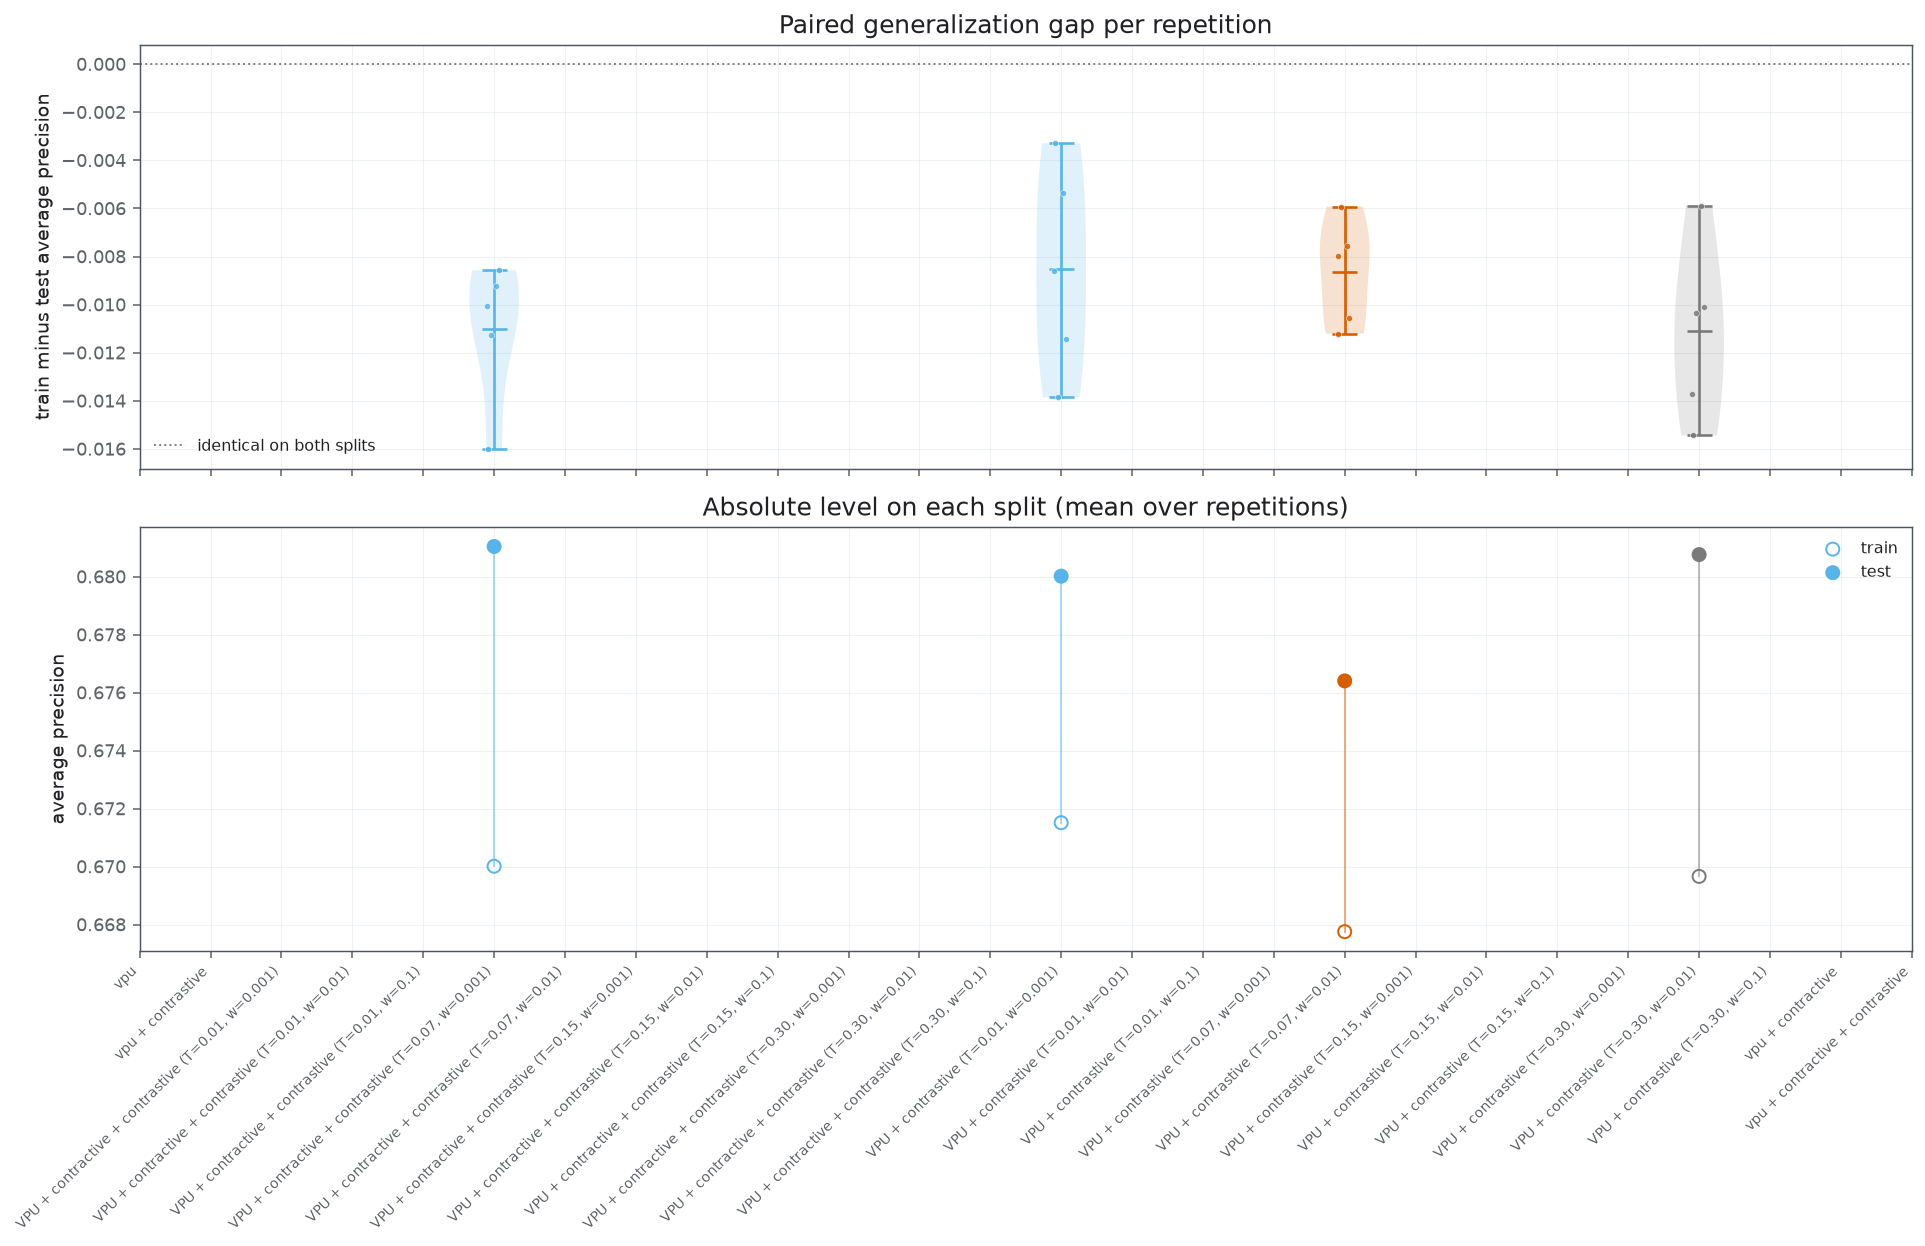

In [8]:
paired = (
    prediction.query("population == @POPULATION and scope == 'train_supported' and metric == 'average_precision'")
    .pivot_table(index=["label", "repetition"], columns="split", values="value")
    .dropna(subset=["train", "test"])
)
paired["gap"] = paired["train"] - paired["test"]

figure, (gap_axis, level_axis) = plt.subplots(2, 1, figsize=(14.0, 9.0), dpi=theme.figure_dpi, sharex=True)

for position, label in enumerate(CONDITION_ORDER):
    if label not in paired.index.get_level_values("label"):
        continue
    plot_violin_with_points(paired.loc[label, "gap"].to_numpy(), position=position, ax=gap_axis, width=0.7, color=LABEL_COLOR[label], point_size=10.0, jitter=0.10, theme=theme)
gap_axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="identical on both splits")
gap_axis.set_xticks(range(len(CONDITION_ORDER)))
gap_axis.tick_params(axis="x", labelbottom=False)
gap_axis.set(ylabel="train minus test average precision", title="Paired generalization gap per repetition")
gap_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
gap_axis.legend(fontsize=8, frameon=theme.legend_frame)

levels = paired.groupby("label")[["train", "test"]].mean().reindex(CONDITION_ORDER).dropna()
positions = [CONDITION_ORDER.index(label) for label in levels.index]
for position, (label, row) in zip(positions, levels.iterrows()):
    level_axis.plot([position, position], [row["train"], row["test"]], color=LABEL_COLOR[label], alpha=0.5, linewidth=1)
level_axis.scatter(positions, levels["train"], facecolors="none", edgecolors=[LABEL_COLOR[l] for l in levels.index], s=45, label="train")
level_axis.scatter(positions, levels["test"], color=[LABEL_COLOR[l] for l in levels.index], s=45, label="test")
level_axis.set_xticks(range(len(CONDITION_ORDER)))
level_axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)
level_axis.set(ylabel="average precision", title="Absolute level on each split (mean over repetitions)")
level_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
level_axis.legend(fontsize=8, frameon=theme.legend_frame)

figure.tight_layout()

## Class-frequency dependence

### Methodology

#### Theoretical

A macro average weights every class equally regardless of how many training positives
it had. Plotting per-class validation average precision against the class's own
training positive count shows whether a condition's quality is uniform across the
frequency spectrum or concentrated on classes that were already well supported.

#### Implementation

One point per (condition, class) pair, from the base `per_class` table on the
validation split, population `annotation_retrieval`, eligible classes only.

#### Figure descriptions

x-axis: training positive count for the class (log). y-axis: validation average
precision for that class under that condition. Colour: condition. A flat cloud at low
counts means the condition is not exploiting scarce classes any better than chance; a
rising trend at low counts (relative to another condition) is a rare-class advantage.

### Remarks

### Notes

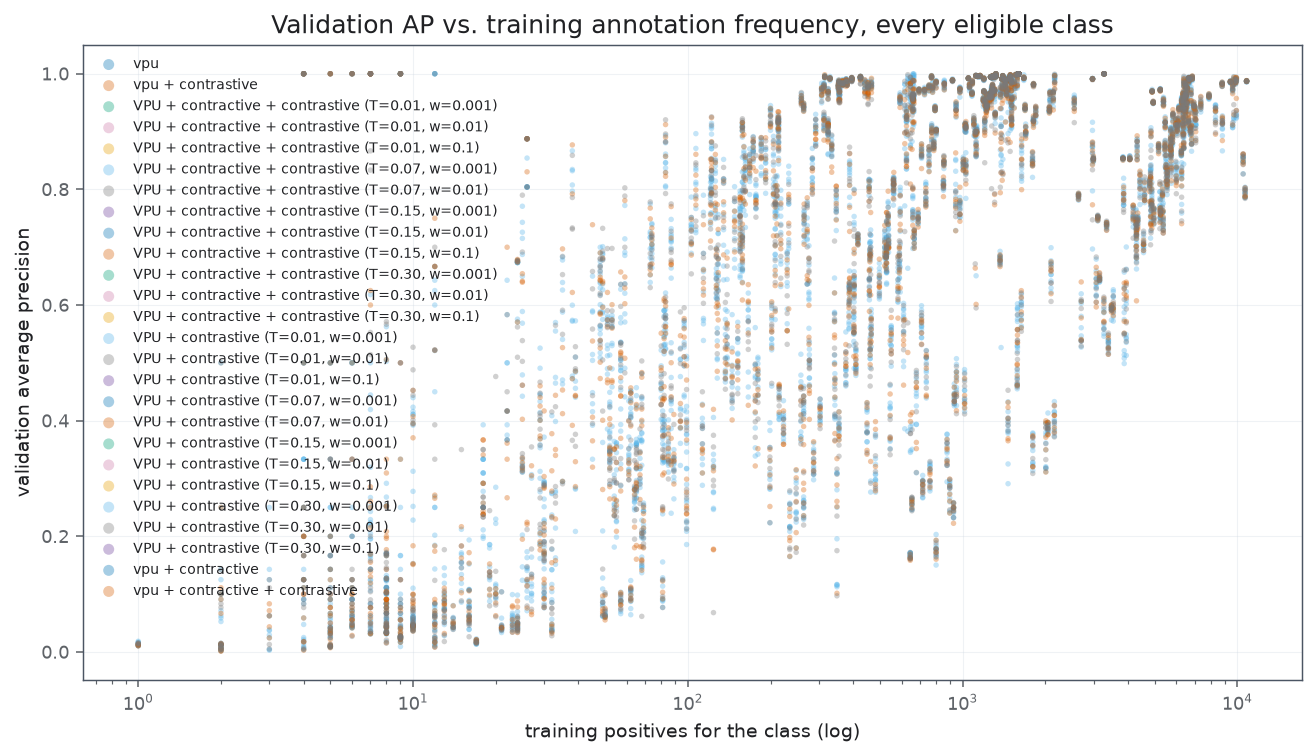

In [9]:
frequency_dependence = per_class.query("split == 'validation' and population == @POPULATION and eligible")

figure, axis = plt.subplots(figsize=(9.5, 5.5), dpi=theme.figure_dpi)
for label in CONDITION_ORDER:
    subset = frequency_dependence.query("label == @label")
    axis.scatter(subset["train_positives"], subset["average_precision"], s=8, alpha=0.35,
                color=LABEL_COLOR[label], edgecolor="none", label=label)
axis.set_xscale("log")
axis.set(xlabel="training positives for the class (log)", ylabel="validation average precision",
        title="Validation AP vs. training annotation frequency, every eligible class")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=7, frameon=theme.legend_frame, markerscale=2)
figure.tight_layout()

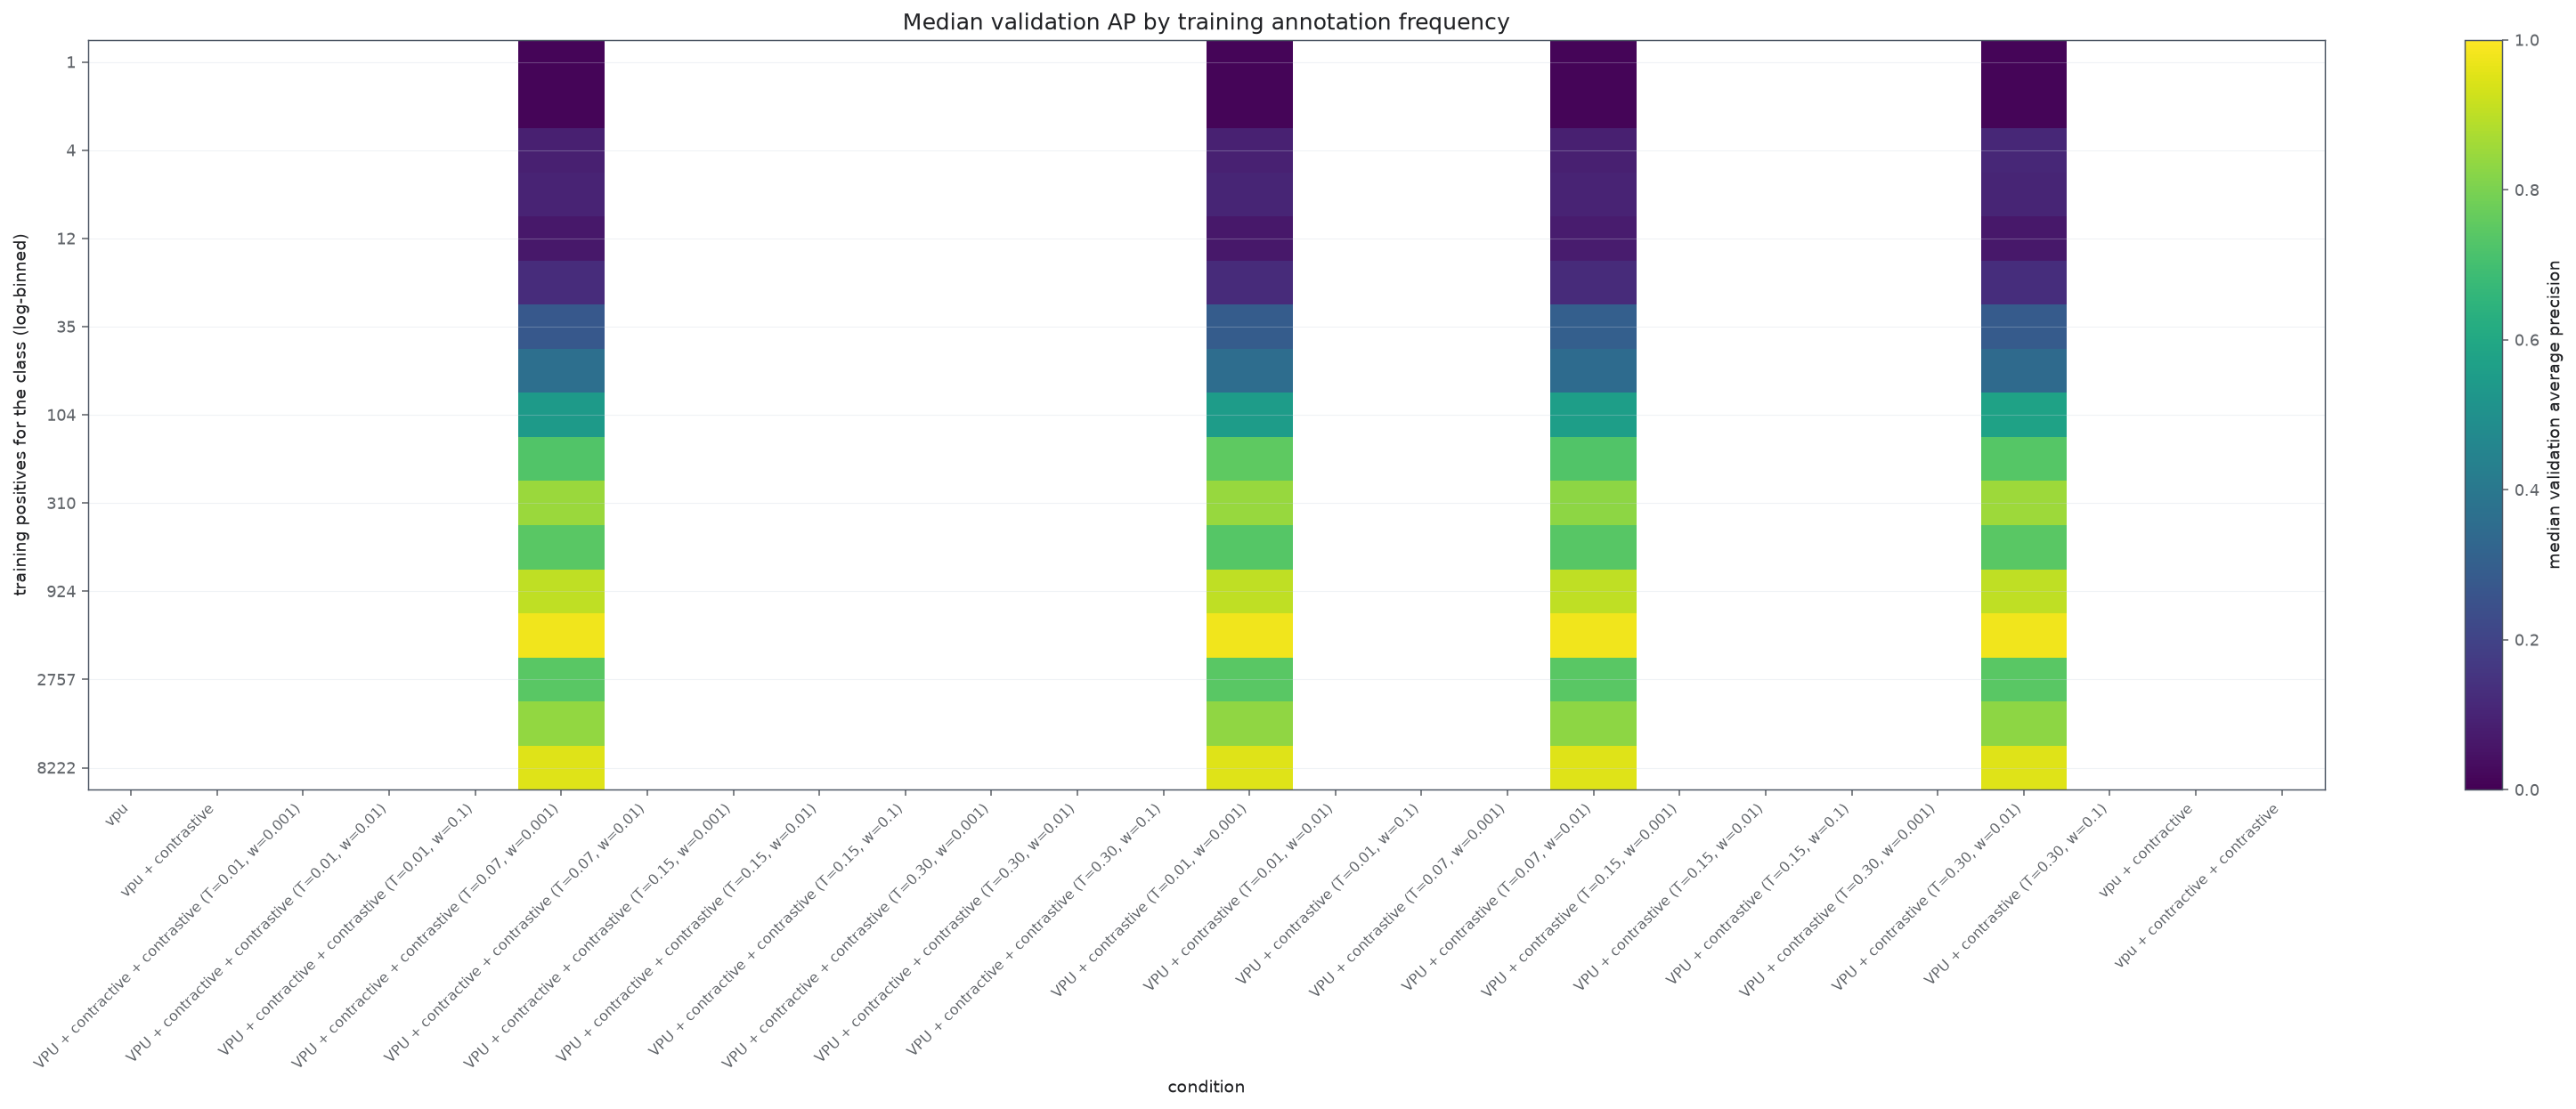

In [10]:
frequency_dependence = per_class.query("split == 'validation' and population == @POPULATION and eligible").copy()

# REMARK: `duplicates="drop"` and the `nunique` guard below protect against a
# degenerate bin edge set (every eligible class sharing one `train_positives` value,
# or too few distinct values for 18 log-spaced edges to stay unique) — pre-existing
# fragility, surfaced by running this notebook against a small/synthetic fixture
# rather than the real 508-class campaign, where it was never observed.
if frequency_dependence["train_positives"].nunique() > 1:
    bins = np.logspace(
        np.log10(frequency_dependence["train_positives"].min()),
        np.log10(frequency_dependence["train_positives"].max()),
        18,
    )
    frequency_dependence["frequency_bin"] = pd.cut(
        frequency_dependence["train_positives"],
        bins=bins,
        include_lowest=True,
        duplicates="drop",
    )
else:
    bins = np.array([frequency_dependence["train_positives"].min(), frequency_dependence["train_positives"].max() + 1])
    frequency_dependence["frequency_bin"] = pd.Categorical([f"{bins[0]:.0f}"] * len(frequency_dependence))

frequency_summary = (
    frequency_dependence.groupby(["label", "frequency_bin"], observed=True)["average_precision"]
    .median()
    .unstack()
    .reindex(CONDITION_ORDER)
)

baseline_values = frequency_summary.loc[baseline_label]
better_than_baseline = frequency_summary.gt(baseline_values, axis=1)
fraction_better = better_than_baseline.mean(axis=1)

figure, axis = plt.subplots(figsize=(0.75 * len(CONDITION_ORDER) + 4.0, 9.0), dpi=theme.figure_dpi)
image = axis.imshow(
    frequency_summary.T.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
for x, label in enumerate(CONDITION_ORDER):
    for y, better in enumerate(better_than_baseline.loc[label]):
        if better:
            axis.add_patch(
                plt.Rectangle(
                    (x - 0.5, y - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5,
                )
            )
axis.set_xticks(range(len(CONDITION_ORDER)))
axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=8)
for tick, label in zip(axis.get_xticklabels(), CONDITION_ORDER):
    if fraction_better.loc[label] > 0.5:
        tick.set_fontweight("bold")
        tick.set_color("black")

centers = np.sqrt(bins[:-1] * bins[1:])
shown = np.arange(0, len(centers), 2)
axis.set_yticks(shown)
axis.set_yticklabels([f"{centers[i]:.0f}" for i in shown])
axis.set(
    xlabel="condition",
    ylabel="training positives for the class (log-binned)",
    title="Median validation AP by training annotation frequency",
)
colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("median validation average precision")
figure.tight_layout()

## Per-class average precision

### Methodology

#### Theoretical

A macro average over several hundred classes is one number over a heterogeneous
population. The per-class distribution shows whether a condition helps broadly or
trades some classes against others.

#### Implementation

Per-class records come from the base `per_class` table, evaluation split, population
`annotation_retrieval`, eligible classes only, pooled over repetitions.

#### Figure descriptions

Left: per condition, the distribution of per-class average precision (violin: every
eligible class; points: a fixed-size random subsample, since several hundred points per
violin is unreadable). Right: for the baseline and the best/worst condition by macro
average precision, each class's training positive count (log) against its average
precision.

### Remarks

### Notes

In [11]:
PER_CLASS_POINT_SAMPLE = 1_000

point_rng = np.random.default_rng(SAMPLE_SEED)
eligible_test = per_class.query("split == @SPLIT and population == @POPULATION and eligible")

median_by_label = eligible_test.groupby("label")["average_precision"].median()
baseline_median = median_by_label[baseline_label]

figure, (distribution_axis, prevalence_axis) = plt.subplots(2, 1, figsize=(15.0, 10.0), dpi=theme.figure_dpi)

for position, label in enumerate(CONDITION_ORDER):
    values = eligible_test.query("label == @label")["average_precision"].dropna().to_numpy()
    if not len(values):
        continue
    shown = values if len(values) <= PER_CLASS_POINT_SAMPLE else point_rng.choice(values, PER_CLASS_POINT_SAMPLE, replace=False)
    distribution_axis.violinplot([values], positions=[position], widths=0.7, showmeans=False, showmedians=True)
    distribution_axis.scatter(position + point_rng.normal(0.0, 0.06, size=len(shown)), shown, color=LABEL_COLOR[label], s=4, alpha=0.35, edgecolor="none")
    distribution_axis.text(position, np.median(values) + 0.025, f"{np.median(values):.3f}", ha="center", va="bottom", fontsize=7)

distribution_axis.axhline(baseline_median, color="grey", linestyle="--", linewidth=1, label=f"{baseline_label} median = {baseline_median:.3f}")
distribution_axis.set_xticks(range(len(CONDITION_ORDER)))
distribution_axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)

for tick, label in zip(distribution_axis.get_xticklabels(), CONDITION_ORDER):
    if label in median_by_label and median_by_label[label] > baseline_median:
        tick.set_fontweight("bold")

distribution_axis.set(ylabel="per-class average precision", title=f"Per-class distribution (points: {PER_CLASS_POINT_SAMPLE} sampled)")
distribution_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
distribution_axis.legend(fontsize=7, frameon=theme.legend_frame)

macro_ranking = summary_table["average_precision"].dropna().sort_values()
highlight = [baseline_label, macro_ranking.index[-1], macro_ranking.index[0]]

for label in dict.fromkeys(highlight):
    subset = eligible_test.query("label == @label")
    prevalence_axis.scatter(subset["train_positives"], subset["average_precision"], color=LABEL_COLOR.get(label, "grey"), s=14, alpha=0.55, edgecolor="none", label=label)

prevalence_axis.set_xscale("log")
prevalence_axis.set(xlabel="training positives for the class (log)", ylabel="per-class average precision", title="Prevalence dependence: baseline, best and worst condition")
prevalence_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
prevalence_axis.legend(fontsize=7, frameon=theme.legend_frame)

figure.tight_layout()

KeyError: 'vpu'

## Contrast against the baseline

### Methodology

#### Theoretical

Repetition $r$ of any two conditions shares its split and data-loader seeds and differs
only in initialization/training seeds, so the comparison should be paired. A condition
is called separated from the baseline when its interval excludes zero; with 8 swept
conditions against one baseline and no multiple-comparison correction, a single
near-boundary condition is weak evidence.

#### Implementation

`experimental_units`/`paired_comparisons`/`baseline_contrasts` (shared with `part_3`'s
own baseline-contrast section) applied to `average_precision`, population
`annotation_retrieval`, scope `train_supported`, evaluation split.

#### Figure descriptions

Table: one row per condition, the mean paired difference in average precision against
the baseline and its 95% across-seed interval. Figure: the same as an error-bar plot,
black-edged markers where the interval excludes zero.

### Remarks

### Notes

2026-09-19 19:32:58,137 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:194 | Oriented 66 baseline contrasts as candidate minus reference.


,label,pairs,mean_difference,ci_low,ci_high
1,vpu + contractive + contrastive,5,-0.0044,-0.0121,0.0033
13,vpu + contractive,5,0.0002,-0.0047,0.0051


2026-09-19 19:32:58,192 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:336 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/segmentation_model/17_09_26_metaspace_heads_vpu_contractive/part_4_prediction_global_results.


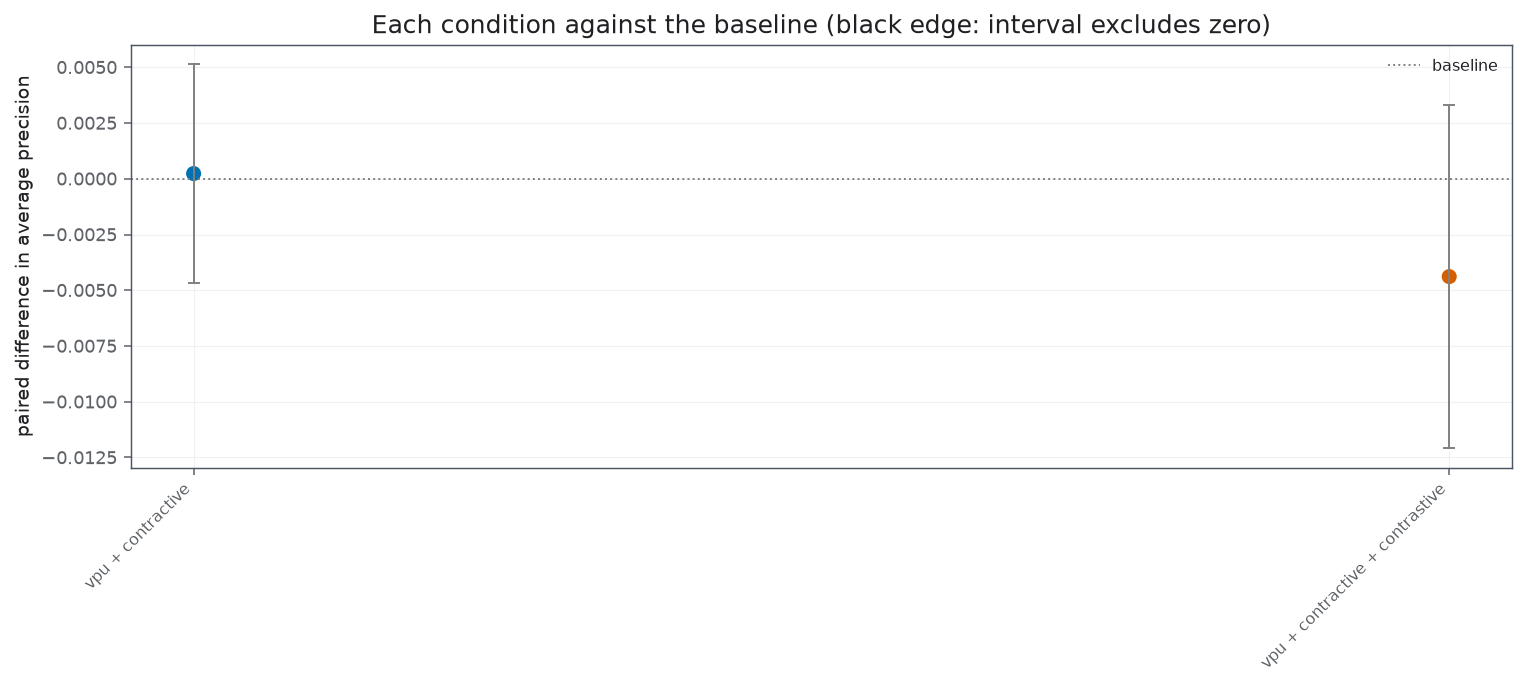

In [ ]:
# `groups` must name at least one measurement key (paired_comparisons groups its
# per-pair differences by it); "metric" is used even though the display below narrows
# to `average_precision`, so the same call also yields roc_auc/ap_above_prevalence and
# (for the eligible conditions) the threshold-based contrasts for free, persisted below.
CONTRAST_METRIC_ORDER = METRIC_ORDER + THRESHOLD_METRIC_ORDER
contrast_source = prediction.query("split == @SPLIT and population == @POPULATION and scope == 'train_supported' and metric in @CONTRAST_METRIC_ORDER")
units = reports.experimental_units(contrast_source, ready, ["metric"])
_, contrasts = reports.paired_comparisons(units, ["metric"])
baseline_contrasts = reports.baseline_contrasts(contrasts, ready)
display(baseline_contrasts.query("metric == 'average_precision'")[["label", "pairs", "mean_difference", "ci_low", "ci_high"]].round(4))

ap_contrasts = baseline_contrasts.query("metric == 'average_precision'")
plotted = ap_contrasts.dropna(subset=["mean_difference"]).set_index("label").reindex(
    [label for label in CONDITION_ORDER if label in ap_contrasts.label.values])
positions = np.arange(len(plotted))
figure, axis = plt.subplots(figsize=(11.0, 5.0), dpi=theme.figure_dpi)
axis.errorbar(positions, plotted["mean_difference"],
             yerr=[plotted["mean_difference"] - plotted["ci_low"], plotted["ci_high"] - plotted["mean_difference"]],
             fmt="none", ecolor="grey", elinewidth=1, capsize=3)
axis.scatter(positions, plotted["mean_difference"], s=60, color=[LABEL_COLOR[l] for l in plotted.index],
            edgecolor=["black" if ci_low > 0 or ci_high < 0 else "none"
                       for ci_low, ci_high in zip(plotted["ci_low"], plotted["ci_high"])], linewidth=1.2)
axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="baseline")
axis.set_xticks(positions)
axis.set_xticklabels(plotted.index, rotation=45, ha="right", fontsize=8)
axis.set(ylabel="paired difference in average precision", title="Each condition against the baseline (black edge: interval excludes zero)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

reports.save_tables(RESULTS, baseline_contrasts=baseline_contrasts)

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the base precompute runner, not
here; this notebook adds only `baseline_contrasts.csv`, a cheap derived aggregation of
tables already in memory.

The results directory is deliberately not versioned: it is regenerable.

### Remarks

### Notes

In [ ]:
print("derived tables written:", sorted(path.name for path in RESULTS.glob("*.csv")))

derived tables written: ['baseline_contrasts.csv']


## Results / Summary

### LLM

Executed against the real campaign cache (120 models, 508 classes, 2026-09-14).

**The scoring-bug fix (see "Threshold-based prediction metrics") changed three conditions'
ranking numbers substantially, from apparently-broken to in line with the rest of the
campaign:** `evidential_taylor_vpu` AP 0.027→0.594 (ROC-AUC 0.023→0.982), `selective_pn`
AP 0.027→0.551 (ROC-AUC 0.039→0.964), `selective_taylor_vpu_plus_simulated_negative` AP
0.027→0.630 (ROC-AUC 0.030→0.985). These were never failing models —
`positive_scores` was reading the wrong channel for `SelectiveHead`/`EvidentialHead`.
Every table in this notebook (and in `part_3`/`part_5`/`part_6`/`part_7`, not yet
re-executed as of this note) reflects the corrected scores from here on.

**Ranking (`average_precision`, population `annotation_retrieval`, scope
`train_supported`, test split):** the baseline `balanced_bce` scores 0.6746. Among the
original 8-condition `vpu_precision_sweep` grid, none of the 4 conditions with a paired
95% CI excluding zero beat the baseline — `pu_ranking` is clearly worse (−0.195),
`pn_bce_global_positive_penalty`/`pn_bce_unweighted`/`pn_bce_per_class_positive_penalty`
are each worse by 0.06-0.07; `bce_global_positive_penalty`, `pnu_ce`, `vpu` and
`bce_per_class_positive_penalty` are statistically indistinguishable from baseline.
Across the full 20-condition set (added `predictive_expanded`/`_jerm` sources), `vpu`
(0.6825) and `pnu_ce`/`bce_per_class_positive_penalty` (~0.680) are the top ranking
conditions; `pu_ranking` (0.480), `taylor_vpu` (0.443) and — now correctly measured —
`deep_gambler_pn` (0.251) remain the weakest.

**Threshold metrics (macro/micro F1, precision, recall, Hamming loss) are defined for
17 of the 20 conditions** — every family whose own training theory targets a genuine
positive-class probability, not only the literal-BCE ones (see the section above for
the full per-family justification); `NaN` only for `pu_ranking` (no probability
anchor exists at all) and the two three-state heads (answered separately by `part_8`).
Ranking quality and threshold behaviour diverge in informative ways once every eligible
condition is visible:

- **Best calibrated overall:** `vpu` has the lowest Hamming loss (0.0158) and highest
  micro-precision (0.8307) of any condition, with middling recall (0.855) — a
  conservative, well-calibrated positive-probability estimate, consistent with VPU's
  theoretical guarantee of a valid posterior under the (here, correctly specified)
  class prior.
- **Worst calibrated despite reasonable ranking:** `taylor_vpu` has by far the highest
  Hamming loss (0.131) and lowest micro-precision (0.273) among eligible conditions,
  driven by near-total recall (0.992, F1 0.431) — it ranks positives above negatives
  reasonably well (ROC-AUC 0.976) but its raw score sits far on the positive side of
  0.5 almost everywhere, i.e. uncalibrated rather than undiscriminating.
  `vpu_plus_simulated_negative` shows the opposite failure (recall 0.297, precision-
  heavy), and `deep_gambler_pn`'s threshold metrics (F1 0.157) confirm its ranking
  weakness is real, not a scoring artifact.
- **BCE-family and DeepGambler/Taylor-VPU-hybrid conditions cluster together** at
  F1 0.50-0.61, micro-F1 0.55-0.84 — `bce_per_class_positive_penalty`/
  `bce_global_positive_penalty` remain the best-calibrated of the classic BCE variants
  (micro-F1 ~0.84, Hamming loss ~0.018-0.019); `jerm_alternating_spy_plus_simulated_negative`
  (micro-F1 0.788) and `deep_gambler_taylor_vpu_plus_simulated_negative` (micro-F1
  0.761) both land in the same competitive band, despite neither being literal-BCE.
- **A large gap between AP and threshold quality is itself diagnostic**: `evidential_taylor_vpu`
  (AP 0.594, but recall 0.905 vs. precision 0.459 — F1 0.549) discriminates reasonably
  but its Dirichlet-mean threshold runs positive-heavy, worth a calibration pass if this
  condition is carried forward.

Full numbers for every eligible condition are in the `threshold_summary_table` output
above; nothing here should be read as final model selection — that synthesis belongs in
`part_7`.

### Person